In [3]:
import numpy as np
from fake_spectra.plot_spectra import PlottingSpectra
from fake_spectra.spectra import Spectra
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from lyaemu import lyman_data
from lyaemu import flux_power

Reading pre-computed spectra (from file output/SPECTRA_000/gridded_spectra.hdf5  )
100  sightlines. resolution:  1.0002664127439553  z= 5.000024000096
Reading pre-computed spectra (from file output/SPECTRA_001/gridded_spectra.hdf5  )
100  sightlines. resolution:  1.0004415761996515  z= 4.600044800358402
Reading pre-computed spectra (from file output/SPECTRA_002/gridded_spectra.hdf5  )
100  sightlines. resolution:  1.0003716592394294  z= 4.200208008320333


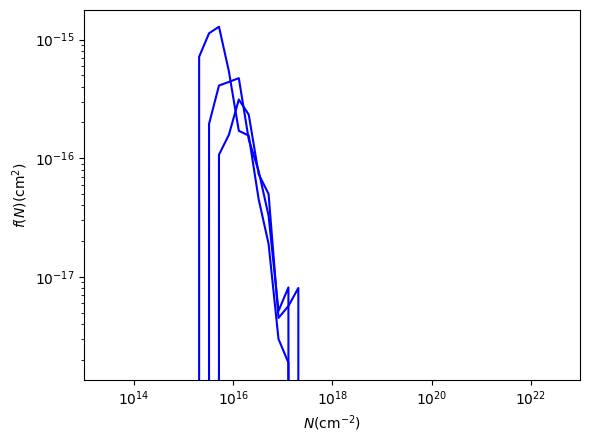

In [ ]:
# Plot the column density function
for i in range(3):
    ps = PlottingSpectra(num=i,base="output", savefile="gridded_spectra.hdf5", label=f"num={i}")
    ps.plot_cddf("H",1)

np.int64(582)

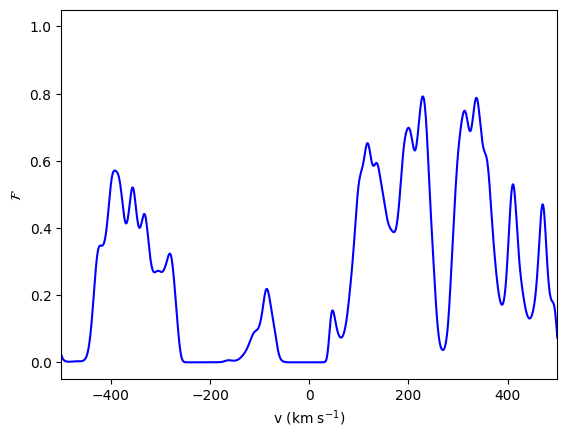

In [18]:
# Plot the flux power spectrum function
ps.plot_spectrum("H",1,1215,9)

In [11]:
# Flux power spectrum post analysis
def post_analysis(i, tau):
    # To just spectra
    gs = Spectra(i, "output", MPI=None, res=1.0, savefile="gridded_spectra.hdf5", cofm=None, axis=None)
    fps = gs.get_flux_power_1D("H",1,mean_flux_desired=np.exp(-tau))     # get 1D flux power spectrum
    # Save spectra to file
    np.savetxt("output/SPECTRA_%03d/flux_power.txt" % (i), fps, fmt="%.4e")
    return fps

# Do the chi2 analysis for the flux power spectrum
def chi_squared(expected, observed, sigma_sq):
    # observed is the fit, expected is the original spectrum
    return (expected - observed)**2/sigma_sq

Reading pre-computed spectra (from file output/SPECTRA_002/gridded_spectra.hdf5  )
100  sightlines. resolution:  1.0003716592394294  z= 4.200208008320333
Chi-squared value: 19.778 at z = 4.2



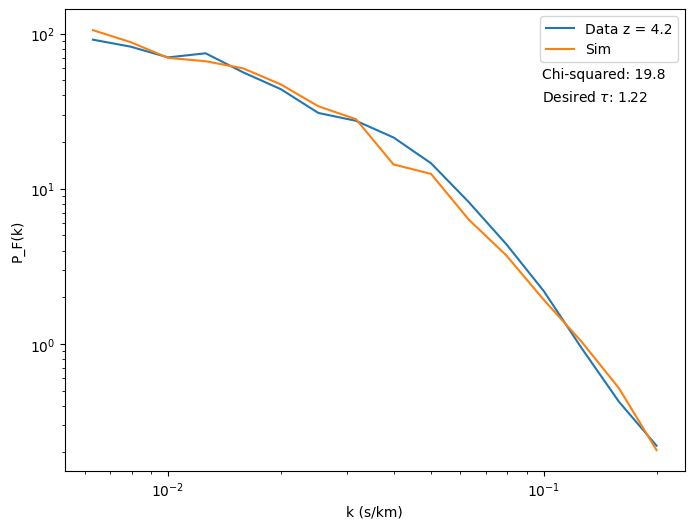

Reading pre-computed spectra (from file output/SPECTRA_001/gridded_spectra.hdf5  )
100  sightlines. resolution:  1.0004415761996515  z= 4.600044800358402
Chi-squared value: 70.601 at z = 4.6



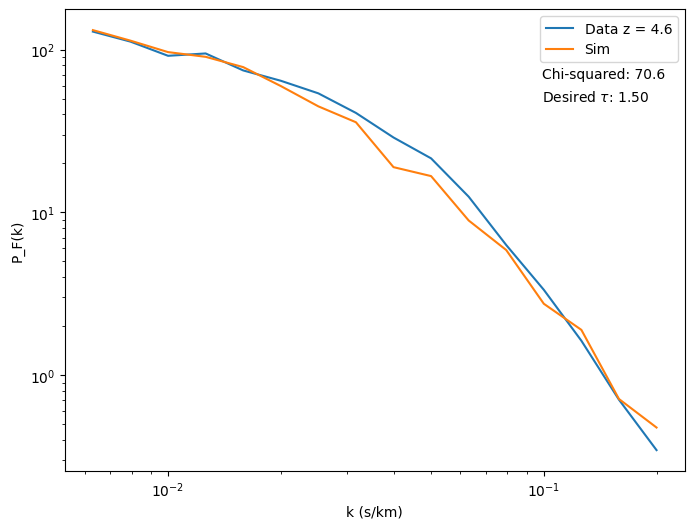

Reading pre-computed spectra (from file output/SPECTRA_000/gridded_spectra.hdf5  )
100  sightlines. resolution:  1.0002664127439553  z= 5.000024000096
Chi-squared value: 82.455 at z = 5.0



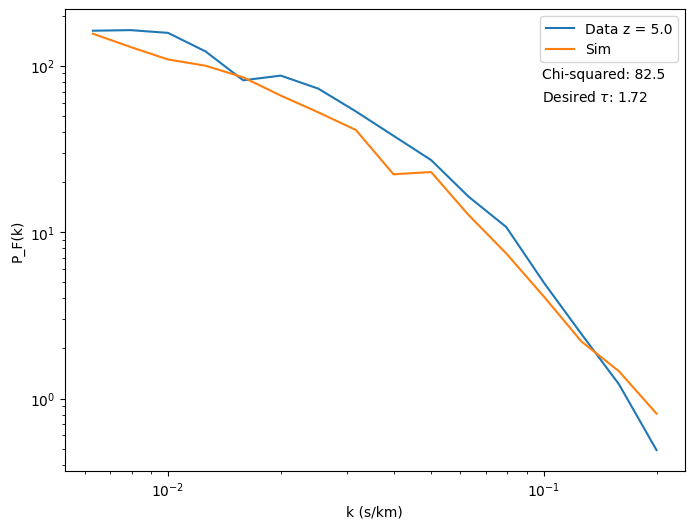

In [12]:
# Three redshifts
z = [4.2, 4.6, 5.0]
obser_data = lyman_data.BoeraData()
kf = obser_data.get_kf()    # km / s

# Best fit results
z_tau = [1.21523361, 1.50100554, 1.7171031 ] 
chi_2 = [19.77462124, 70.61763039, 82.45744833]

# Extract the observed power spectrum for different redshifts
zout = flux_power.MySpectra(max_z = 5.0, redshifts=z, pixel_resolution_km_s=1.0).zout
data_power  = obser_data.pf.reshape(-1, kf.shape[0]) #km / s; n_z * n_k # n_z * n_k
sigma_sq    = obser_data.covar_diag.reshape(-1, kf.shape[0])

# Do the chi2 analysis for each redshift
for i, z in enumerate(zout):
    i_inv = 2 - i

    # Preparing data for the current redshift
    post_analysis(i_inv, z_tau[i])
    sim = np.loadtxt("output/SPECTRA_%03d/flux_power.txt" % (i_inv))

    skf = sim[0,:]          # km / s
    sim_power = sim[1,:]    # P_F(k) for the simulated data at the current redshift

    # Rebinning simulated data to match the k bins of the observed data
    interp_func = interp1d(skf, sim_power, kind='linear', bounds_error=False, fill_value="extrapolate")
    sim_power_rebinned = interp_func(kf)

    # chi2 analysis
    chi2 = chi_squared(sim_power_rebinned, data_power[i], sigma_sq[i])
    print(f"Chi-squared value: {np.sum(chi2):.3f} at z = {z:.1f}\n")

    plt.figure(figsize=(8,6))
    plt.plot(kf, data_power[i], label="Data z = %.1f" % z)
    plt.plot(kf, sim_power_rebinned, label="Sim")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("k (s/km)")
    plt.ylabel("P_F(k)")
    plt.text(0.77, 0.85, f"Chi-squared: {np.sum(chi2):.1f}", transform=plt.gca().transAxes)
    plt.text(0.77, 0.8, f"Desired $\\tau$: {z_tau[i]:.2f}", transform=plt.gca().transAxes)
    plt.legend()
    plt.show()